In [1]:
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "global_PCA"))

import fm
from apply_pca import load_pca, apply_pca
import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

RAW_PLOTS = Path("raw_plots")
RAW_PLOTS.mkdir(exist_ok=True)

BED_PATH = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

pca_model = load_pca()
print(f"PCA: {pca_model['n_components']} components, "
      f"explained variance: {pca_model['explained_variance_ratio'].sum():.1%}")

accessor = TwoBitAccessor(str(TWOBIT_PATH))
print("2bit accessor ready")

Device: mps
PCA: 16 components, explained variance: 85.4%
2bit accessor ready


## Panel B — PCA scatter: tRNA similarity vs irrelevant miRNA

Two tRNA-Asn (same anticodon GTT) should cluster tightly in RNA-FM PCA space.
A miRNA (ENST00000362168.1) should separate clearly.
MMD quantifies the distributional distance.

In [2]:
PANEL_B_TRANSCRIPTS = {
    "tRNA-Asn-GTT-chr1-140": {"color": "#1a3a5c", "label": "tRNA-Asn (copy 1)"},
    "tRNA-Asn-GTT-chr1-139": {"color": "#6baed6", "label": "tRNA-Asn (copy 2)"},
    "ENST00000362168.1":     {"color": "#e8720c", "label": "miRNA (MIR103A1)"},
}

bed_data = read_bed12_file(str(BED_PATH))
target_ids = set(PANEL_B_TRANSCRIPTS.keys())

transcripts = {}
for t in bed_data:
    if t.id in target_ids:
        transcripts[t.id] = t

assert len(transcripts) == len(target_ids), (
    f"Found {len(transcripts)}/{len(target_ids)}: "
    f"missing {target_ids - set(transcripts.keys())}"
)

sequences = {}
for tid, t in transcripts.items():
    seq = sn._get_spliced_sequence(t, accessor)
    sequences[tid] = seq
    print(f"{tid}: {len(seq)} nt")

print(f"\nLoaded {len(sequences)} transcripts")

ENST00000362168.1: 110 nt
tRNA-Asn-GTT-chr1-140: 74 nt
tRNA-Asn-GTT-chr1-139: 74 nt

Loaded 3 transcripts


In [3]:
model_rnafm, alphabet = fm.pretrained.rna_fm_t12()
model_rnafm.eval().to(device)
batch_converter = alphabet.get_batch_converter()

def get_token_embeddings(seq: str) -> np.ndarray:
    """RNA-FM layer-12 token embeddings -> PCA-projected (L, 16)."""
    rna_seq = seq.upper().replace("T", "U")
    data = [("seq", rna_seq)]
    _, _, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        results = model_rnafm(batch_tokens, repr_layers=[12])
    emb = results["representations"][12][0, 1:1 + len(rna_seq), :]
    emb_np = emb.cpu().numpy()
    return apply_pca(emb_np, pca_model)


In [4]:

embeddings_b = {}
for tid, seq in sequences.items():
    emb_pca = get_token_embeddings(seq)
    embeddings_b[tid] = emb_pca
    print(f"{tid}: embedding shape {emb_pca.shape}")

print("Embeddings ready")

ENST00000362168.1: embedding shape (110, 16)
tRNA-Asn-GTT-chr1-140: embedding shape (74, 16)
tRNA-Asn-GTT-chr1-139: embedding shape (74, 16)
Embeddings ready


In [5]:
tids = list(PANEL_B_TRANSCRIPTS.keys())
mmd_pairs = {}
for i in range(len(tids)):
    for j in range(i + 1, len(tids)):
        mmd_val = sn._compute_mmd(embeddings_b[tids[i]], embeddings_b[tids[j]])
        pair_label = f"{PANEL_B_TRANSCRIPTS[tids[i]]['label']}  vs  {PANEL_B_TRANSCRIPTS[tids[j]]['label']}"
        mmd_pairs[(tids[i], tids[j])] = mmd_val
        print(f"MMD  {pair_label}: {mmd_val:.4f}")

print("\nMMD computation done")

MMD  tRNA-Asn (copy 1)  vs  tRNA-Asn (copy 2): 0.0000
MMD  tRNA-Asn (copy 1)  vs  miRNA (MIR103A1): 0.2863
MMD  tRNA-Asn (copy 2)  vs  miRNA (MIR103A1): 0.2646

MMD computation done


Saved: raw_plots/fig1B.pdf


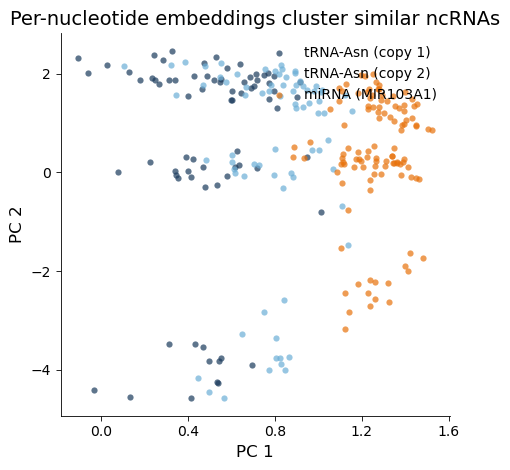


MMD values for fig1B
  tRNA-Asn (copy 1)  vs  tRNA-Asn (copy 2): 0.0000
  tRNA-Asn (copy 1)  vs  miRNA (MIR103A1): 0.2863
  tRNA-Asn (copy 2)  vs  miRNA (MIR103A1): 0.2646


In [6]:
fig, ax = plt.subplots(figsize=(4.8, 4.8))

for tid, meta in PANEL_B_TRANSCRIPTS.items():
    emb = embeddings_b[tid]
    ax.scatter(
        emb[:, 0], emb[:, 1],
        c=meta["color"],
        label=meta["label"],
        s=20, alpha=0.7, linewidths=0, zorder=3,
    )

ax.set_title("Per-nucleotide embeddings cluster similar ncRNAs", fontsize=14)
ax.set_xlabel("PC 1", fontsize=12)
ax.set_ylabel("PC 2", fontsize=12)
ax.tick_params(labelsize=10, width=0.6)

ax.xaxis.set_major_locator(plt.MaxNLocator(5))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.6)
ax.spines["bottom"].set_linewidth(0.6)

ax.legend(fontsize=10, loc="upper right", frameon=False)

out_path = RAW_PLOTS / "fig1B.pdf"
fig.tight_layout()
fig.savefig(out_path, format="pdf")
print(f"Saved: {out_path}")
plt.show()

tids = list(PANEL_B_TRANSCRIPTS.keys())
print()
print("=" * 50)
print("MMD values for fig1B")
print("=" * 50)
for (t1, t2), v in mmd_pairs.items():
    l1 = PANEL_B_TRANSCRIPTS[t1]["label"]
    l2 = PANEL_B_TRANSCRIPTS[t2]["label"]
    print(f"  {l1}  vs  {l2}: {v:.4f}")
print("=" * 50)

## Panel C — Mean-pooled PCA: real ncRNAs vs noise

Mean-pooled RNA-FM embeddings (1 dot per sequence) separate real ncRNAs
from intergenic genomic noise and random shuffled sequences in PCA space.

In [7]:
import random
import pandas as pd

random.seed(42)
np.random.seed(42)

META_PATH = REPO_ROOT / "input_data" / "reference_annotation" / "test_sample.metadata.tsv"
meta_df = pd.read_csv(META_PATH, sep="\t")
biotype_map = dict(zip(meta_df["transcript_id"], meta_df["transcript_biotype"]))

N_PER_BIOTYPE = 50
NOISE_N = 150
RANDOM_N = 100
NOISE_LEN = 100

MAX_SEQ_LEN = 300

PANEL_C_BIOTYPES = {
    "tRNA":   {"color": "#1b9e77", "n": N_PER_BIOTYPE},
    "snoRNA": {"color": "#d95f02", "n": 39},
    "miRNA":  {"color": "#7570b3", "n": N_PER_BIOTYPE},
}

bed_data_c = read_bed12_file(str(BED_PATH))

by_biotype = {bt: [] for bt in PANEL_C_BIOTYPES}
for t in bed_data_c:
    tid_base = t.id.split(".")[0]
    if t.id.startswith("tRNA-") and "Und-NNN" not in t.id:
        by_biotype["tRNA"].append(t)
    elif tid_base in biotype_map and biotype_map[tid_base] in PANEL_C_BIOTYPES:
        by_biotype[biotype_map[tid_base]].append(t)

ncrna_sequences = {}
for bt, cfg in PANEL_C_BIOTYPES.items():
    pool = by_biotype[bt]
    random.shuffle(pool)
    sampled = pool[:cfg["n"]]
    for t in sampled:
        seq = sn._get_spliced_sequence(t, accessor)
        if seq and "N" not in seq.upper() and 20 <= len(seq) <= MAX_SEQ_LEN:
            ncrna_sequences[t.id] = (bt, seq)
    print(f"{bt}: {sum(1 for v in ncrna_sequences.values() if v[0] == bt)} sequences")

print(f"\nTotal ncRNA sequences: {len(ncrna_sequences)}")

tRNA: 50 sequences
snoRNA: 39 sequences
miRNA: 50 sequences

Total ncRNA sequences: 139


In [8]:
chrom_sizes = accessor.chrom_sizes()
main_chroms = [c for c in chrom_sizes if c.startswith("chr") and "_" not in c and c != "chrM"]

intergenic_seqs = []
attempts = 0
while len(intergenic_seqs) < NOISE_N and attempts < NOISE_N * 10:
    attempts += 1
    chrom = random.choice(main_chroms)
    max_start = chrom_sizes[chrom] - NOISE_LEN
    if max_start <= 0:
        continue
    start = random.randint(0, max_start)
    seq_obj = accessor.fetch(chrom, start, start + NOISE_LEN)
    seq_str = seq_obj.to_string()
    if "N" not in seq_str.upper() and len(seq_str) == NOISE_LEN:
        if not seq_obj.is_rna:
            seq_obj = seq_obj.toggle_type()
        intergenic_seqs.append(seq_obj.to_string())

print(f"Intergenic noise: {len(intergenic_seqs)} sequences ({NOISE_LEN} nt each)")

all_real_seqs = [seq for _, seq in ncrna_sequences.values()]
shuffled_seqs = []
for _ in range(RANDOM_N):
    donor = random.choice(all_real_seqs)
    nts = list(donor)
    random.shuffle(nts)
    shuffled_seqs.append("".join(nts))

print(f"Random shuffled: {len(shuffled_seqs)} sequences")

Intergenic noise: 150 sequences (100 nt each)
Random shuffled: 100 sequences


In [9]:
def get_mean_pooled_pca(seq: str) -> np.ndarray:
    """RNA-FM -> mean pool -> PCA: returns (16,) vector."""
    rna_seq = seq.upper().replace("T", "U")
    data = [("seq", rna_seq)]
    _, _, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        results = model_rnafm(batch_tokens, repr_layers=[12])
    emb = results["representations"][12][0, 1:1 + len(rna_seq), :]
    mean_emb = emb.mean(dim=0).cpu().numpy()
    return apply_pca(mean_emb, pca_model)

pca_c = {}

for tid, (bt, seq) in ncrna_sequences.items():
    pca_c[tid] = (bt, get_mean_pooled_pca(seq))
print(f"ncRNA embeddings: {len(pca_c)}")

intergenic_pca = np.array([get_mean_pooled_pca(s) for s in intergenic_seqs])
print(f"Intergenic embeddings: {intergenic_pca.shape}")

shuffled_pca = np.array([get_mean_pooled_pca(s) for s in shuffled_seqs])
print(f"Shuffled embeddings: {shuffled_pca.shape}")

ncRNA embeddings: 139
Intergenic embeddings: (150, 16)
Shuffled embeddings: (100, 16)


Saved: raw_plots/fig1C.pdf


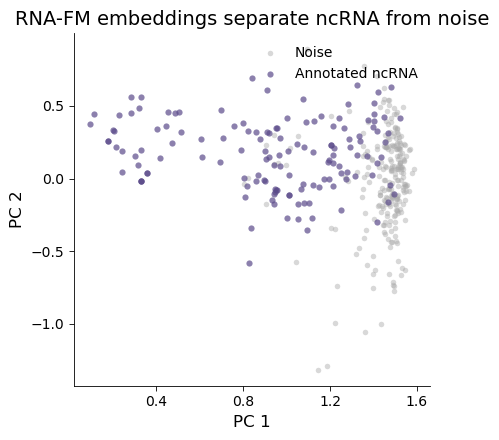

In [10]:
COLOR_RNA = "#5B4B8A"
COLOR_NOISE = "#AAAAAA"

noise_pca = np.vstack([intergenic_pca, shuffled_pca])
rna_pca = np.array([v for _, (_, v) in pca_c.items()])

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(
    noise_pca[:, 0], noise_pca[:, 1],
    c=COLOR_NOISE, label="Noise", s=16, alpha=0.45,
    linewidths=0, zorder=1,
)
ax.scatter(
    rna_pca[:, 0], rna_pca[:, 1],
    c=COLOR_RNA, label="Annotated ncRNA", s=20, alpha=0.7,
    linewidths=0, zorder=3,
)

ax.set_xlabel("PC 1", fontsize=12)
ax.set_ylabel("PC 2", fontsize=12)
ax.set_title("RNA-FM embeddings separate ncRNA from noise", fontsize=14)
ax.tick_params(labelsize=10, width=0.6)

ax.xaxis.set_major_locator(plt.MaxNLocator(5))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.6)
ax.spines["bottom"].set_linewidth(0.6)

ax.legend(fontsize=10, loc="upper right", frameon=False)

out_path = RAW_PLOTS / "fig1C.pdf"
fig.tight_layout()
fig.savefig(out_path, format="pdf")
print(f"Saved: {out_path}")
plt.show()

In [11]:
print("=" * 50)
print("Data summary for fig1C")
print("=" * 50)
print()
print("--- Annotated ncRNA ---")
bt_counts = {}
for _, (bt, _) in pca_c.items():
    bt_counts[bt] = bt_counts.get(bt, 0) + 1
for bt, n in sorted(bt_counts.items()):
    print(f"  {bt:>10s}: {n:>4d}")
print(f"  {'TOTAL':>10s}: {sum(bt_counts.values()):>4d}")
print()
print("--- Noise ---")
print(f"  {'intergenic':>18s}: {len(intergenic_seqs):>4d}  ({NOISE_LEN} nt each)")
print(f"  {'shuffled (dinucl)':>18s}: {len(shuffled_seqs):>4d}")
print(f"  {'TOTAL':>18s}: {len(intergenic_seqs) + len(shuffled_seqs):>4d}")
print("=" * 50)

Data summary for fig1C

--- Annotated ncRNA ---
       miRNA:   50
      snoRNA:   39
        tRNA:   50
       TOTAL:  139

--- Noise ---
          intergenic:  150  (100 nt each)
   shuffled (dinucl):  100
               TOTAL:  250


## Panel D — Boundary perturbation sensitivity

Average per-position Euclidean displacement in 16D PCA space when the 5' boundary
is shifted by ±1 nt, computed over many short ncRNAs (truncated to 100 nt).
Shows that perturbation effects accumulate toward the 3' end.

In [ ]:
TRUNC_LEN = 100
N_TARGETS = 50

meta_df_d = pd.read_csv(META_PATH, sep="\t")
biotype_map_d = dict(zip(meta_df_d["transcript_id"], meta_df_d["transcript_biotype"]))
ncrna_biotypes = {"miRNA", "snoRNA"}

candidates = []
for t in read_bed12_file(str(BED_PATH)):
    if len(t.blocks) != 1:
        continue
    seq_len = int(t.blocks[0][1]) - int(t.blocks[0][0])
    if seq_len < TRUNC_LEN:
        continue
    tid_base = t.id.split(".")[0]
    is_trna = t.id.startswith("tRNA-") and "Und-NNN" not in t.id
    is_ncrna = tid_base in biotype_map_d and biotype_map_d[tid_base] in ncrna_biotypes
    if is_trna or is_ncrna:
        candidates.append(t)

random.seed(42)
random.shuffle(candidates)
candidates = candidates[:N_TARGETS]
print(f"Selected {len(candidates)} single-exon ncRNAs (>= {TRUNC_LEN} nt)")

all_dists_plus = []
all_dists_minus = []
all_orig_embs = []
skipped = 0

for t in candidates:
    chrom = t.chrom
    g_start, g_end = int(t.blocks[0][0]), int(t.blocks[0][1])
    strand = t.strand

    if strand == -1:
        rna_5p_genomic = g_end
        g_end_orig = g_start + (g_end - g_start)
        g_start_trunc = g_end - TRUNC_LEN
        if g_start_trunc < 0:
            skipped += 1; continue
        orig_seq = sn._extract_sequence(accessor, chrom, g_start_trunc, g_end, strand)
        plus_seq = sn._extract_sequence(accessor, chrom, g_start_trunc, g_end + 1, strand)
        minus_seq = sn._extract_sequence(accessor, chrom, g_start_trunc, g_end - 1, strand)
    else:
        g_end_trunc = g_start + TRUNC_LEN
        orig_seq = sn._extract_sequence(accessor, chrom, g_start, g_end_trunc, strand)
        if g_start < 1:
            skipped += 1; continue
        plus_seq = sn._extract_sequence(accessor, chrom, g_start - 1, g_end_trunc, strand)
        minus_seq = sn._extract_sequence(accessor, chrom, g_start + 1, g_end_trunc, strand)

    if "N" in orig_seq.upper() or "N" in plus_seq.upper() or "N" in minus_seq.upper():
        skipped += 1; continue
    if len(orig_seq) != TRUNC_LEN:
        skipped += 1; continue

    e_orig = get_token_embeddings(orig_seq)     # (100, 16)
    e_plus = get_token_embeddings(plus_seq)     # (101, 16)
    e_minus = get_token_embeddings(minus_seq)   # (99, 16)
    all_orig_embs.append(e_orig)

    dists_plus = np.linalg.norm(e_orig - e_plus[1:1 + TRUNC_LEN], axis=1)
    all_dists_plus.append(dists_plus)

    dists_minus = np.linalg.norm(e_orig[1:] - e_minus, axis=1)
    padded = np.full(TRUNC_LEN, np.nan)
    padded[1:] = dists_minus
    all_dists_minus.append(padded)

print(f"Processed: {len(all_dists_plus)}, skipped: {skipped}")

avg_plus = np.nanmean(all_dists_plus, axis=0)
avg_minus = np.nanmean(all_dists_minus, axis=0)
avg_both = np.nanmean([avg_plus, avg_minus], axis=0)

Selected 50 single-exon ncRNAs (>= 100 nt)
Processed: 50, skipped: 0


/var/folders/z7/ft06s3jj3qggbhqby221m2200000kt/T/ipykernel_40310/3418481921.py:74: RuntimeWarning: Mean of empty slice
  avg_minus = np.nanmean(all_dists_minus, axis=0)


: 

In [ ]:
from scipy.spatial.distance import pdist

pooled = np.vstack(all_orig_embs)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(pooled), size=min(500, len(pooled)), replace=False)
pairwise = pdist(pooled[sample_idx], metric="euclidean")

print(f"Embedding space stats (16D PCA, {len(pairwise)} pairs):")
print(f"  mean dist:   {np.mean(pairwise):.2f}")
print(f"  median dist: {np.median(pairwise):.2f}")
print(f"  max dist:    {np.max(pairwise):.2f}")

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.axvspan(TRUNC_LEN - 10, TRUNC_LEN, color="#fee0d2", zorder=0)

ax.plot(range(TRUNC_LEN), avg_plus, color="#1a3a5c", linewidth=1.5, zorder=3,
        label="+1 nt flank")
ax.plot(range(TRUNC_LEN), avg_minus, color="#e8720c", linewidth=1.5, zorder=3,
        label="\u22121 nt trim")

ax.set_xlabel("Nucleotide position", fontsize=11)
ax.set_ylabel("Euclidean distance (16D PCA)", fontsize=11)
ax.tick_params(labelsize=9)

ax.set_xlim(0, TRUNC_LEN)
ax.set_axisbelow(True)
ax.grid(True, alpha=0.15, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=8, loc="upper left", frameon=False)

out_path = RAW_PLOTS / "fig1D.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## Panel F — ROC-AUC: logistic regression signal vs noise classifier

A simple linear classifier on the 16 PCA dimensions separates proper ncRNA
from genomic noise with high accuracy.

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_curve, roc_auc_score

# logreg_data_path = REPO_ROOT / "modules" / "logreg_signal_noise" / "train.npz"
# data = np.load(logreg_data_path)
# X_train, y_train = data["X_train"], data["y_train"]
# X_test, y_test = data["X_test"], data["y_test"]

# print(f"Train: {X_train.shape}  ({y_train.sum():.0f} signal / {(1 - y_train).sum():.0f} noise)")
# print(f"Test:  {X_test.shape}  ({y_test.sum():.0f} signal / {(1 - y_test).sum():.0f} noise)")

# logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
# logreg.fit(X_train, y_train)

# y_prob = logreg.predict_proba(X_test)[:, 1]
# auc = roc_auc_score(y_test, y_prob)
# fpr, tpr, _ = roc_curve(y_test, y_prob)
# print(f"\nROC-AUC: {auc:.4f}")

In [ ]:
# fig, ax = plt.subplots(figsize=(4.5, 4.5))

# ax.plot(fpr, tpr, color="#1a3a5c", linewidth=2, zorder=3)
# ax.plot([0, 1], [0, 1], color="#cccccc", linewidth=1, linestyle="--", zorder=1)

# ax.set_xlabel("False positive rate", fontsize=11)
# ax.set_ylabel("True positive rate", fontsize=11)
# ax.tick_params(labelsize=9)

# ax.text(
#     0.97, 0.05,
#     f"AUC = {auc:.2f}",
#     transform=ax.transAxes,
#     fontsize=10,
#     ha="right", va="bottom",
#     fontweight="bold",
# )

# ax.set_xlim(-0.02, 1.02)
# ax.set_ylim(-0.02, 1.02)
# ax.set_axisbelow(True)
# ax.grid(True, alpha=0.15, linewidth=0.5)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# out_path = RAW_PLOTS / "fig1F.pdf"
# fig.savefig(out_path, bbox_inches="tight")
# print(f"Saved: {out_path}")
# plt.show()